In [1]:
import cv2
import numpy as np
import random
import math
import tkinter as tk
import os
from tkinter import filedialog
import matplotlib.pyplot as plt

In [2]:
# Crop the image to maintain a specific aspect ratio (width:height) before resizing. 
def crop_to_aspect_ratio(image, width=640, height=480):
    
    # Calculate current aspect ratio
    current_height, current_width = image.shape[:2]
    desired_ratio = width / height
    current_ratio = current_width / current_height

    if current_ratio > desired_ratio:
        # Current image is too wide
        new_width = int(desired_ratio * current_height)
        offset = (current_width - new_width) // 2
        cropped_img = image[:, offset:offset+new_width]
    else:
        # Current image is too tall
        new_height = int(current_width / desired_ratio)
        offset = (current_height - new_height) // 2
        cropped_img = image[offset:offset+new_height, :]

    return cv2.resize(cropped_img, (width, height))

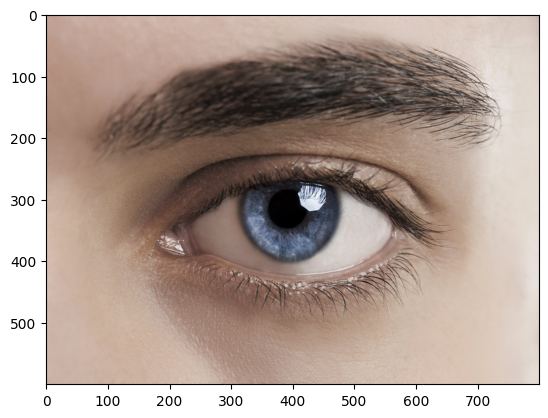

In [9]:
image = cv2.imread('resources/eye.png', cv2.IMREAD_UNCHANGED)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA))
plt.show()

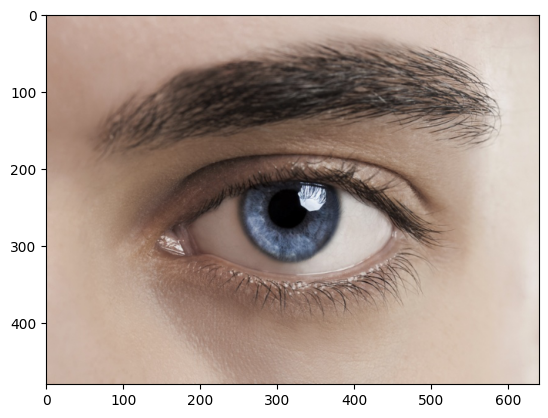

In [13]:
crop = crop_to_aspect_ratio(image)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGRA2RGBA))
plt.show()

In [ ]:
#apply thresholding to an image
def apply_binary_threshold(image, darkestPixelValue, addedThreshold):
    # Calculate the threshold as the sum of the two input values
    threshold = darkestPixelValue + addedThreshold
    # Apply the binary threshold
    _, thresholded_image = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY_INV)
    
    return thresholded_image

#thresh = apply_binary_threshold(crop)

TypeError: apply_binary_threshold() missing 2 required positional arguments: 'darkestPixelValue' and 'addedThreshold'

In [18]:
def get_darkest_area(image):

    ignoreBounds = 20 #don't search the boundaries of the image for ignoreBounds pixels
    imageSkipSize = 10 #only check the darkness of a block for every Nth x and y pixel (sparse sampling)
    searchArea = 20 #the size of the block to search
    internalSkipSize = 5 #skip every Nth x and y pixel in the local search area (sparse sampling)
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    min_sum = float('inf')
    darkest_point = None

    # Loop over the image with spacing defined by imageSkipSize, ignoring the boundaries
    for y in range(ignoreBounds, gray.shape[0] - ignoreBounds, imageSkipSize):
        for x in range(ignoreBounds, gray.shape[1] - ignoreBounds, imageSkipSize):
            # Calculate sum of pixel values in the search area, skipping pixels based on internalSkipSize
            current_sum = np.int64(0)
            num_pixels = 0
            for dy in range(0, searchArea, internalSkipSize):
                if y + dy >= gray.shape[0]:
                    break
                for dx in range(0, searchArea, internalSkipSize):
                    if x + dx >= gray.shape[1]:
                        break
                    current_sum += gray[y + dy][x + dx]
                    num_pixels += 1

            # Update the darkest point if the current block is darker
            if current_sum < min_sum and num_pixels > 0:
                min_sum = current_sum
                darkest_point = (x + searchArea // 2, y + searchArea // 2)  # Center of the block

    return darkest_point

darkestPixelValue = get_darkest_area(crop)
